In [1]:
from pathlib import Path
import pandas as pd

In [2]:
DATA_DIR=Path('final_data')
classes=["no_dr","mild","moderate","severe","proliferative_dr"]

for cls in classes:
    file=list((DATA_DIR/cls).glob("*"))

    print(cls,len(file))

no_dr 1935
mild 393
moderate 1156
severe 278
proliferative_dr 360


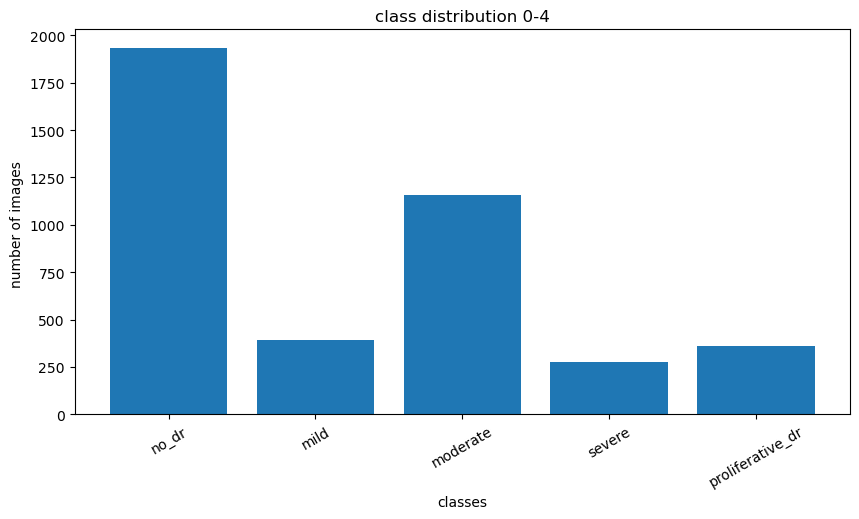

In [3]:
import matplotlib.pyplot as plt 
counts=[]


for cls in classes:
    count=len(list((DATA_DIR/cls).glob("*")))
    counts.append(count)

plt.figure(figsize=(10,5))
plt.bar(classes,counts)
plt.xticks(rotation=30)
plt.ylabel("number of images ")
plt.xlabel("classes")
plt.title("class distribution 0-4")
plt.show()

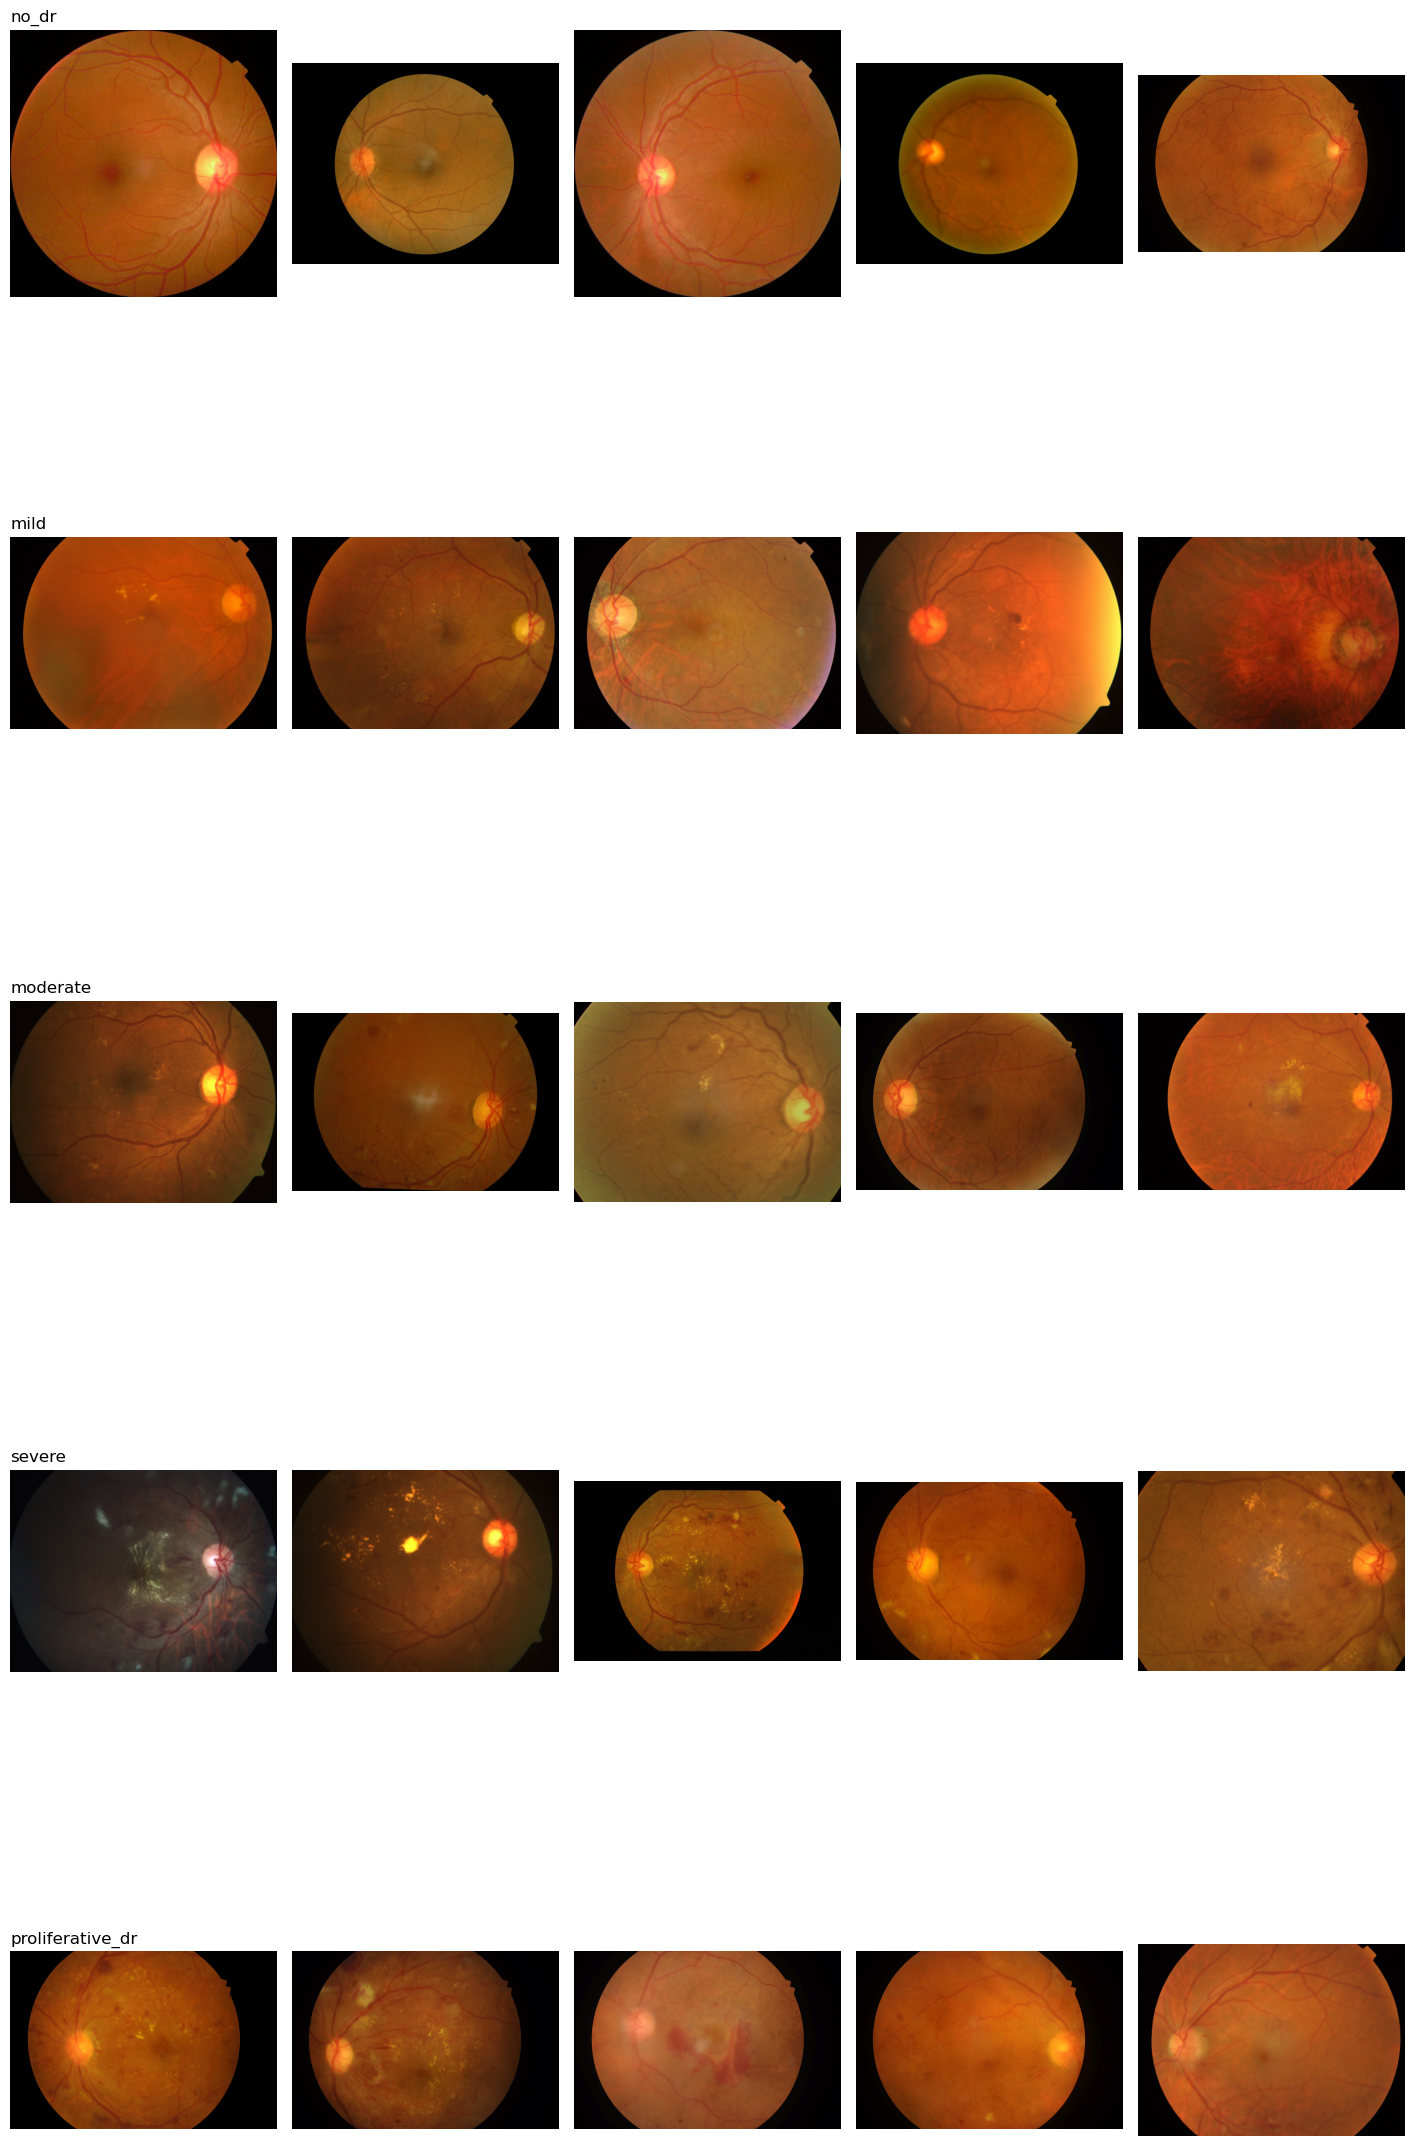

In [4]:
import random
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5 * len(classes)))

for i, cls in enumerate(classes):
    images = list((DATA_DIR / cls).glob("*"))
    selectedImages = random.sample(images, 5)

    for col, imagePath in enumerate(selectedImages):
        image = Image.open(imagePath)

        plt.subplot(len(classes), 5, i * 5 + col + 1)
        plt.imshow(image)
        plt.axis("off")

        if col == 0:
            plt.title(cls, fontsize=12, loc="left")

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

In [5]:
from collections import Counter

sizes = Counter()

for cls in classes:

    for img_path in (DATA_DIR / cls).glob("*"):

        try:
            img = Image.open(img_path)
            sizes[img.size] += 1
        except:
            pass

print(sizes.most_common(20))

[((1050, 1050), 974), ((2416, 1736), 638), ((2588, 1958), 533), ((4288, 2848), 512), ((3216, 2136), 410), ((2048, 1536), 351), ((819, 614), 287), ((3388, 2588), 141), ((1504, 1000), 92), ((1844, 1226), 61), ((640, 480), 42), ((2896, 1944), 34), ((2144, 1424), 28), ((1476, 1117), 14), ((474, 358), 2), ((1467, 1110), 2), ((2146, 1764), 1)]


In [6]:
modes=Counter()
for cls in classes:

    for imgPath in (DATA_DIR/cls).glob("*"):
        try:
            img=Image.open(imgPath)
            modes[img.mode]+=1

        except:
            pass

print(modes)

Counter({'RGB': 4122})


In [7]:
import numpy as np
means=[]
std=[]

for cls in classes:
    for imgPath in (DATA_DIR/cls).glob("*"):
        img=np.array(Image.open(imgPath).convert("RGB"))

        means.append(img.mean())
        std.append(img.std())

print('AVERAWGE picle intesntist',np.mean(means))
print('AVERAWGE picle std deviation',np.mean(std))

AVERAWGE picle intesntist 60.34340117942818
AVERAWGE picle std deviation 56.286358042219746


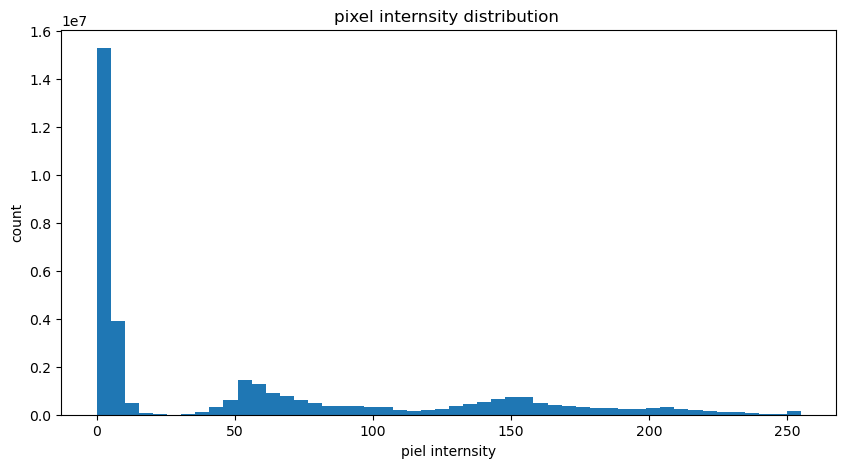

In [8]:
plt.figure(figsize=(10,5))
img=np.array(Image.open(random.choice(list((DATA_DIR/"moderate").glob("*")))).convert("RGB"))

plt.hist(img.ravel(),bins=50)
plt.xlabel("piel internsity")
plt.ylabel("count")
plt.title("pixel internsity distribution ")
plt.show()

In [9]:
import cv2
import numpy as np

def blur_score(image_path):

    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [10]:
scores = []

for cls in classes:

    for img_path in (DATA_DIR / cls).glob("*"):

        score = blur_score(img_path)

        scores.append({
            "class": cls,
            "image": img_path.name,
            "blur_score": score
        })

blur_df = pd.DataFrame(scores)

blur_df['blur_score'].mean

<bound method Series.mean of 0       42.167755
1       27.614819
2       12.599714
3       38.565752
4       45.413593
          ...    
4117    21.678351
4118    24.593121
4119    23.051243
4120    21.339650
4121    23.259378
Name: blur_score, Length: 4122, dtype: float64>

In [11]:
blur_df.head()

,class,image,blur_score
0,no_dr,aptos_002c21358ce6.png,42.167755
1,no_dr,aptos_005b95c28852.png,27.614819
2,no_dr,aptos_0097f532ac9f.png,12.599714
3,no_dr,aptos_00cc2b75cddd.png,38.565752
4,no_dr,aptos_00f6c1be5a33.png,45.413593


In [15]:
records = []

for cls in classes:
    class_dir = DATA_DIR / cls
    
    for img_path in class_dir.glob("*"):
        try:
            img = cv2.imread(str(img_path))
            
            if img is None:
                continue
            
            h, w = img.shape[:2]
            
            if len(img.shape) == 3:
                channels = img.shape[2]
            else:
                channels = 1
            
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            brightness = gray.mean()
            contrast = gray.std()
            
            black_ratio = np.mean(gray < 10)
            
            records.append({
                "class": cls,
                "image": img_path.name,
                "width": w,
                "height": h,
                "channels": channels,
                "aspect_ratio": w / h,
                "brightness": brightness,
                "contrast": contrast,
                "black_ratio": black_ratio
            })
            
        except Exception as e:
            print("Error:", img_path, e)

image_df = pd.DataFrame(records)

print("Total valid images:", len(image_df))

image_df.head()

Total valid images: 4122


,class,image,width,height,channels,aspect_ratio,brightness,contrast,black_ratio
0,no_dr,aptos_002c21358ce6.png,1050,1050,3,1.000000,85.499236,46.504284,0.209263
1,no_dr,aptos_005b95c28852.png,2048,1536,3,1.333333,22.645921,26.404921,0.525915
2,no_dr,aptos_0097f532ac9f.png,2588,1958,3,1.321757,49.541231,16.814747,0.001797
3,no_dr,aptos_00cc2b75cddd.png,1050,1050,3,1.000000,77.169665,41.750427,0.208367
4,no_dr,aptos_00f6c1be5a33.png,1050,1050,3,1.000000,76.716656,41.445276,0.208684


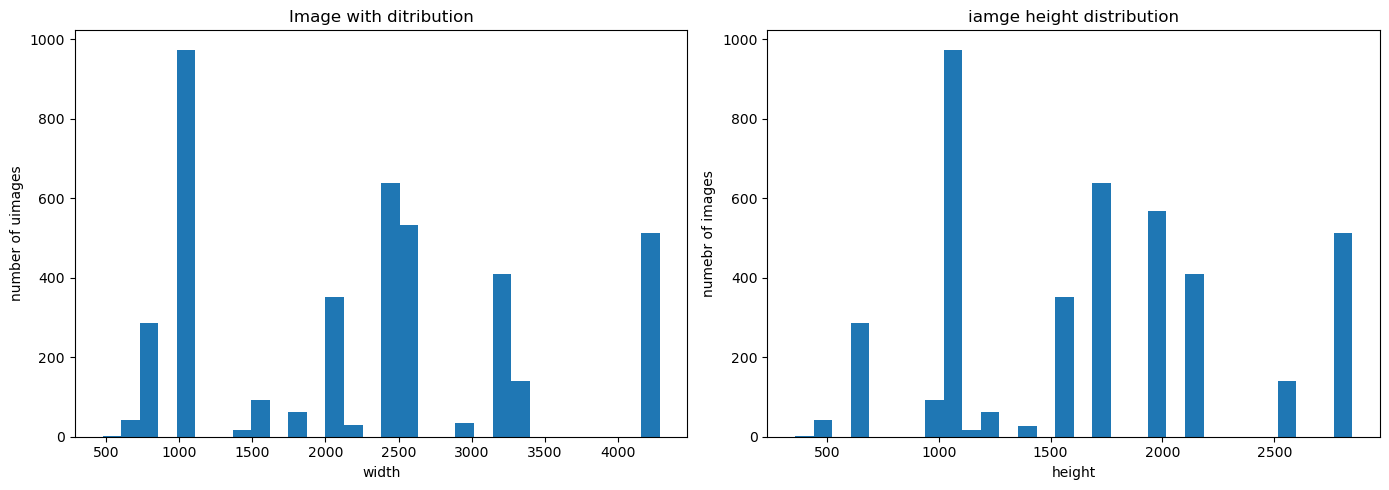

In [18]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(image_df['width'],bins=30)
axes[0].set_title('Image with ditribution')
axes[0].set_xlabel('width')
axes[0].set_ylabel('number of uimages')

axes[1].hist(image_df['height'],bins=30)
axes[1].set_title("iamge height distribution")
axes[1].set_ylabel("numebr of images")
axes[1].set_xlabel("height")

plt.tight_layout()
plt.show()

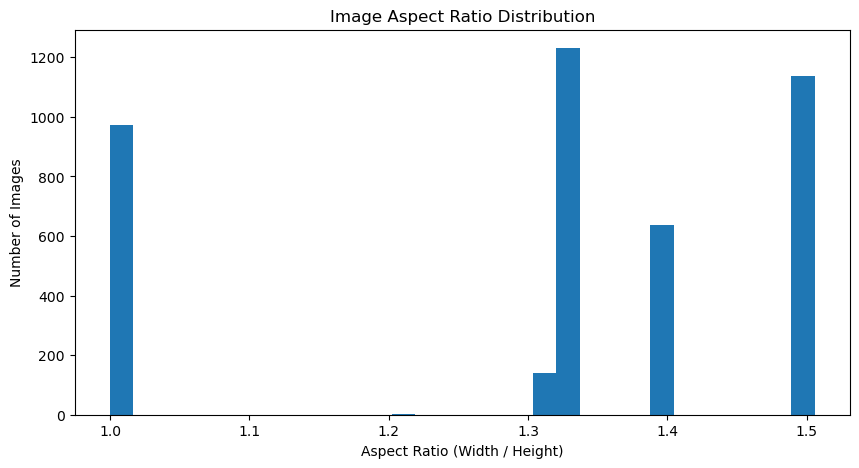

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(image_df["aspect_ratio"], bins=30)

plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")
plt.title("Image Aspect Ratio Distribution")

plt.show()

<Figure size 1000x500 with 0 Axes>

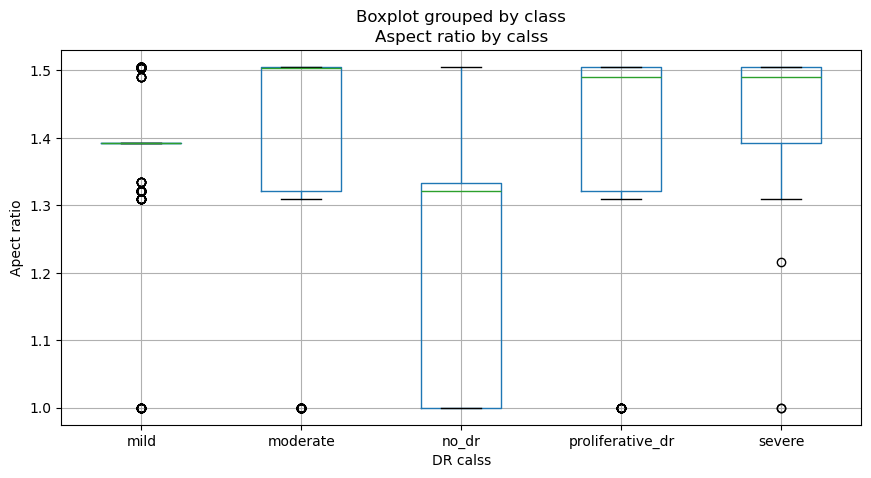

In [24]:
plt.figure(figsize=(10,5))

image_df.boxplot(column='aspect_ratio',by="class",figsize=(10,5))
plt.title("Aspect ratio by calss")
plt.xlabel("DR calss")
plt.ylabel("Apect ratio")
plt.show()

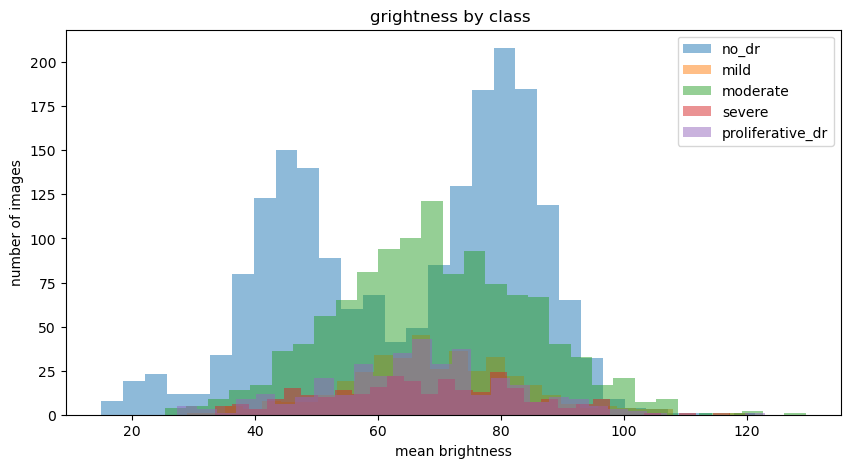

In [27]:
plt.figure(figsize=(10,5))

for cls in classes:
    data=image_df[image_df['class']==cls]['brightness']
    plt.hist(data,bins=30,alpha=0.5,label=cls)

plt.xlabel("mean brightness")
plt.ylabel("number of images")
plt.title("grightness by class ")
plt.legend()

<Axes: title={'center': 'brightness'}, xlabel='class'>

<Figure size 1000x500 with 0 Axes>

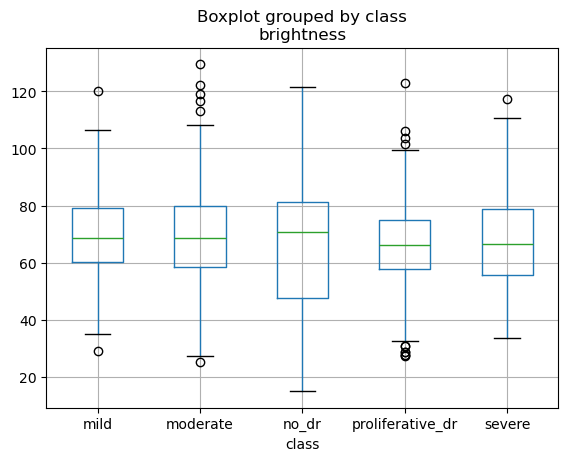

In [28]:
plt.figure(figsize=(10,5))

image_df.boxplot(column='brightness',by='class')

<Figure size 1000x500 with 0 Axes>

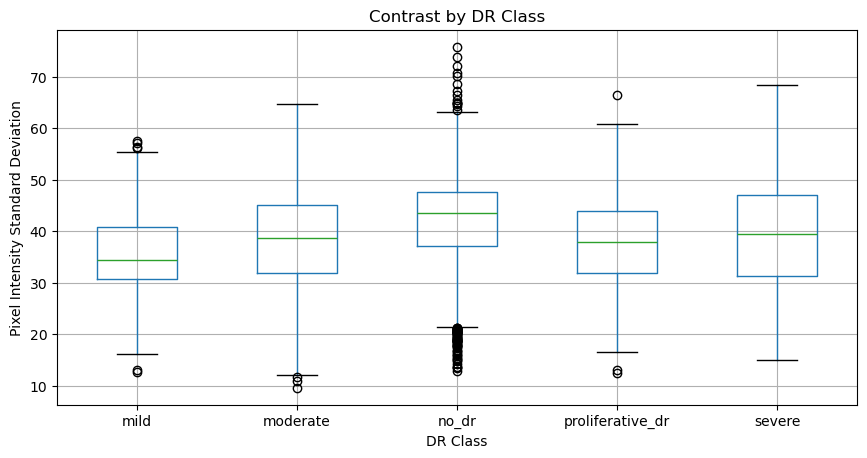

In [30]:
plt.figure(figsize=(10, 5))

image_df.boxplot(
    column="contrast",
    by="class",
    figsize=(10, 5)
)

plt.title("Contrast by DR Class")
plt.suptitle("")
plt.xlabel("DR Class")
plt.ylabel("Pixel Intensity Standard Deviation")

plt.show()

<Axes: title={'center': 'black_ratio'}, xlabel='class'>

<Figure size 1000x500 with 0 Axes>

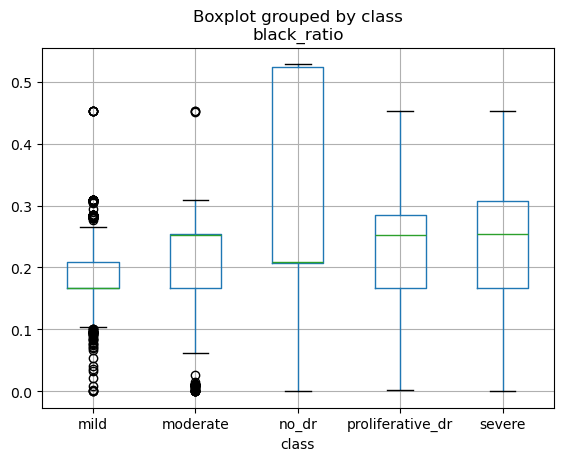

In [37]:
plt.figure(figsize=(10,5))
image_df.boxplot(column="black_ratio",by='class')

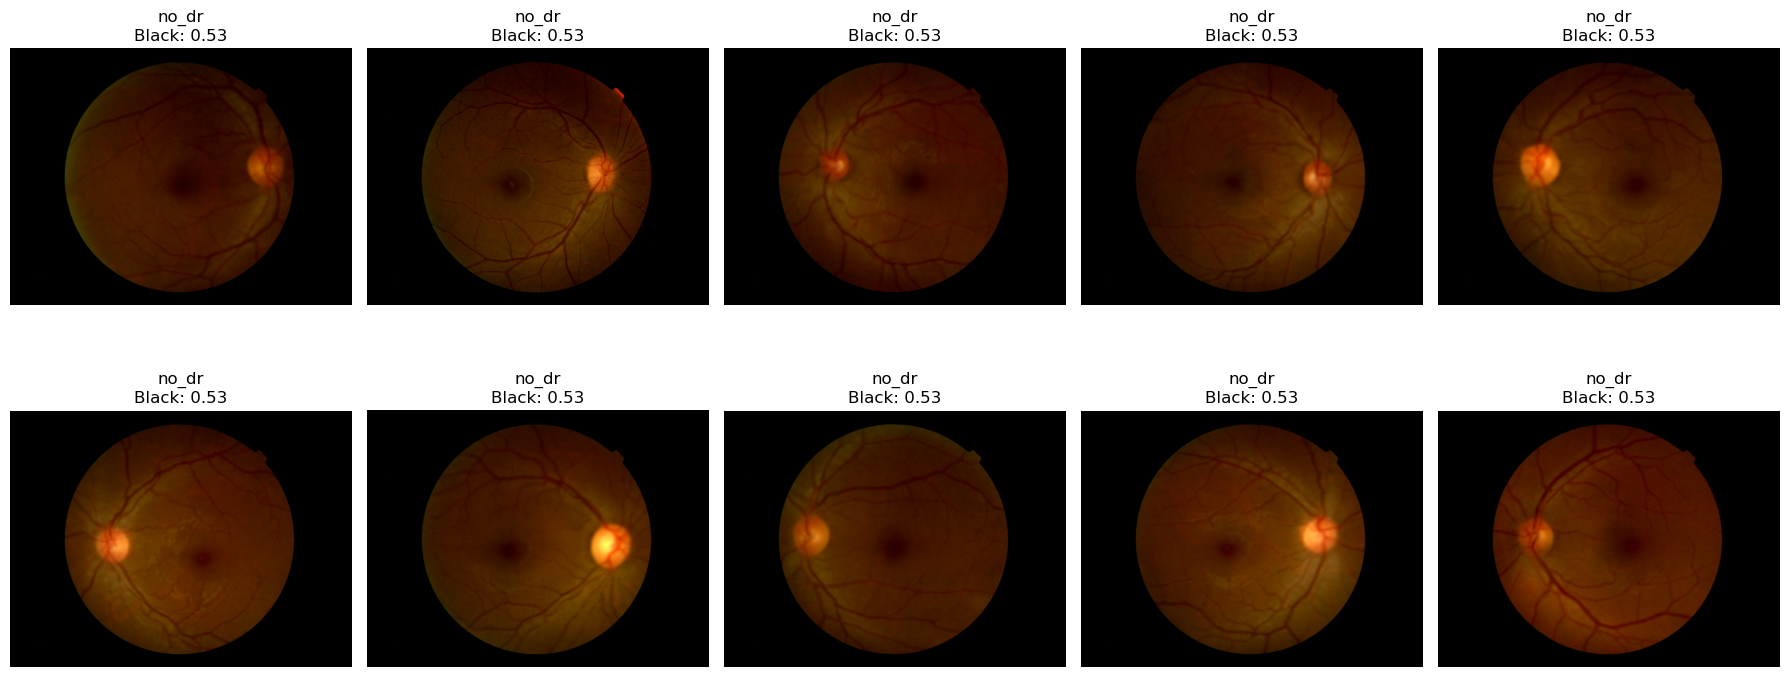

In [48]:
top_black = image_df.sort_values(
    "black_ratio",
    ascending=False
).head(10)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, (_, row) in zip(axes.flat, top_black.iterrows()):
    
    img_path = DATA_DIR / row["class"] / row["image"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(
        f'{row["class"]}\nBlack: {row["black_ratio"]:.2f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

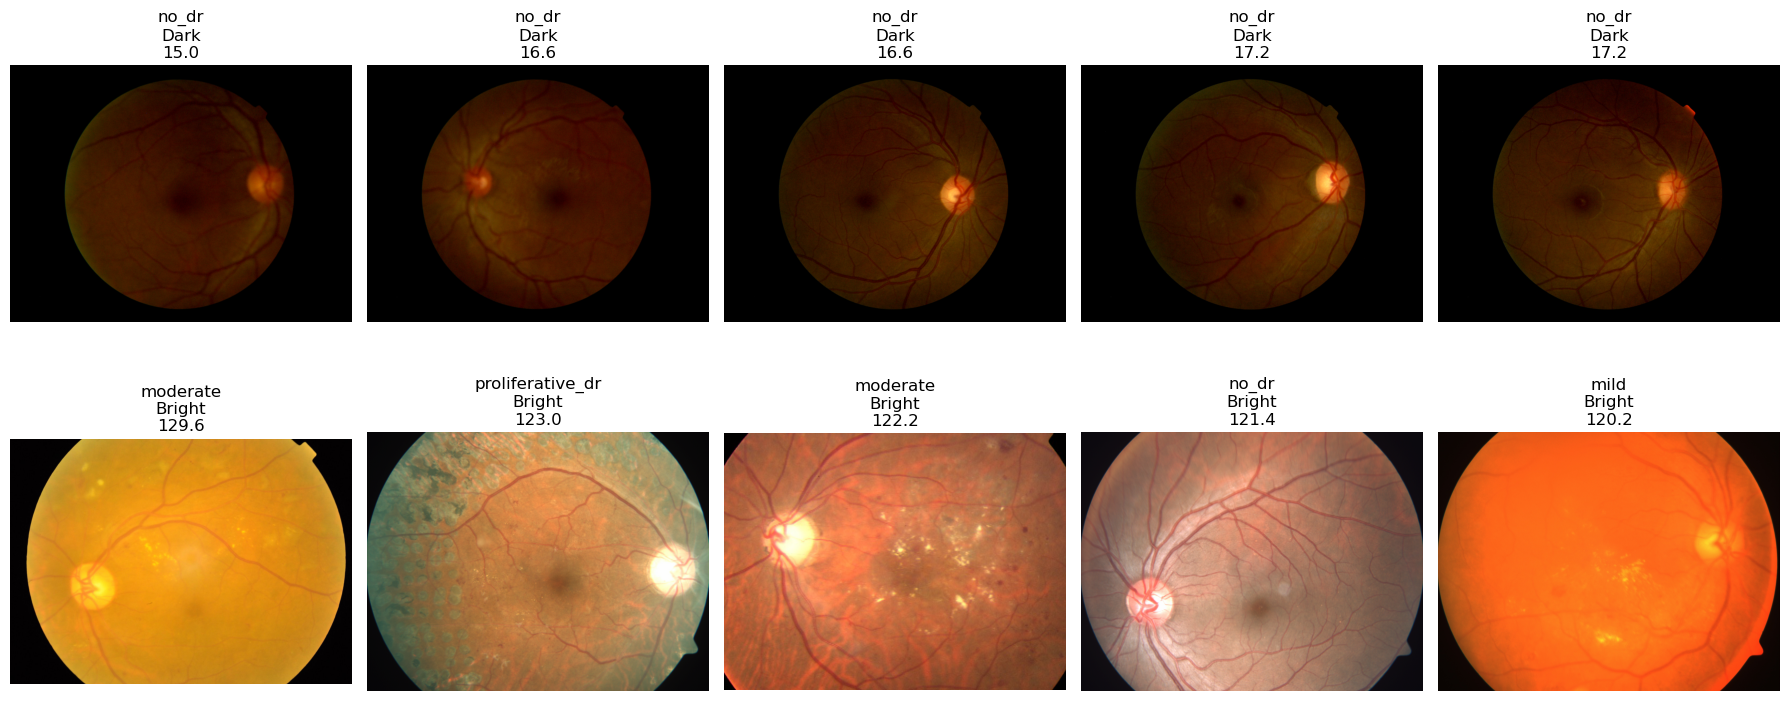

In [49]:
darkest = image_df.nsmallest(5, "brightness")
brightest = image_df.nlargest(5, "brightness")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, (_, row) in zip(axes[0], darkest.iterrows()):
    
    img_path = DATA_DIR / row["class"] / row["image"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(f'{row["class"]}\nDark\n{row["brightness"]:.1f}')
    ax.axis("off")

for ax, (_, row) in zip(axes[1], brightest.iterrows()):
    
    img_path = DATA_DIR / row["class"] / row["image"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(f'{row["class"]}\nBright\n{row["brightness"]:.1f}')
    ax.axis("off")

plt.tight_layout()
plt.show()